# NB01 — Setup, Register Environments & Smoke Test

This notebook verifies all dependencies, registers **both custom Full-Body
environments**, and runs a short smoke test on each.

| Task | Env ID | Robot | DOF |
|------|--------|-------|-----|
| **Main — Place Apple in Bowl** | `UnitreeG1PlaceAppleInBowlFullBody-v1` | `unitree_g1` Full Body | 37 |
| **Bonus — DishWipe** | `UnitreeG1DishWipeFullBody-v1` | `unitree_g1` Full Body | 37 |

Both use the **full-body** Unitree G1 with free-floating root (can walk and
fall). The original upper-body-only variants (25 DOF, fixed legs) are
**no longer used**.


## Objectives

1. Verify all dependencies are installed (Python, NumPy, PyTorch, ManiSkill, SB3, SAPIEN).
2. Import & register both custom environments via `src.envs`.
3. Download required assets (`UnitreeG1PlaceAppleInBowl-v1`).
4. Create **Apple Full-Body** env → inspect obs/act shapes.
5. Create **DishWipe Full-Body** env → inspect obs/act shapes.
6. Discover all 37 active joints grouped by body part.
7. Verify balance API (`is_standing()` / `is_fallen()`).
8. Attempt render test (Vulkan required).
9. Run 50-step smoke test on each env.
10. Reproducibility check + save artifacts + MLflow.


## Resources

| Resource | Requirement | Notes |
|----------|-------------|-------|
| GPU | Not required | CPU-only smoke test |
| RAM | 4 GB | Env creation + 50 steps |
| Disk | ~2 GB | Asset downloads |
| Runtime | ~2-5 min | Full notebook |


## Step 1 — Version Check


In [2]:
import os, sys, platform

# ── Fix Vulkan ICD: use Lavapipe software renderer if NVIDIA ICD is broken ──
_lvp = "/usr/share/vulkan/icd.d/lvp_icd.json"
if os.path.exists(_lvp):
    os.environ["VK_ICD_FILENAMES"] = _lvp
    print(f"Vulkan ICD: Lavapipe ({_lvp})")

print(f"Python   : {sys.version}")
print(f"Platform : {platform.platform()}")
print(f"Machine  : {platform.machine()}")

import numpy as np;          print(f"NumPy    : {np.__version__}")
import torch;                print(f"PyTorch  : {torch.__version__}")
import gymnasium as gym;     print(f"Gymnasium: {gym.__version__}")
import mani_skill;           print(f"ManiSkill: {mani_skill.__version__}")
import sapien;               print(f"SAPIEN   : {sapien.__version__}")
import stable_baselines3 as sb3; print(f"SB3      : {sb3.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

Vulkan ICD: Lavapipe (/usr/share/vulkan/icd.d/lvp_icd.json)
Python   : 3.12.3 (main, Aug 14 2025, 17:47:21) [GCC 13.3.0]
Platform : Linux-6.8.0-90-generic-x86_64-with-glibc2.39
Machine  : x86_64
NumPy    : 2.4.2


PyTorch  : 2.10.0+cu128
Gymnasium: 0.29.1


/root/robotic-sim-dishwash/.env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/root/robotic-sim-dishwash/.env/lib/python3.12/site-packages/sapien/__init__.py:18: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


ManiSkill: 3.0.0b22
SAPIEN   : 3.0.2
SB3      : 2.7.0
CUDA     : True
GPU      : NVIDIA GeForce RTX 5090


## Step 2 — Imports & Register Custom Environments

Importing `src.envs` triggers `@register_env` decorators for both
full-body environments.


In [3]:
import os, json, csv, random, datetime, traceback
from pathlib import Path
from PIL import Image

import mani_skill.envs                          # built-in envs
from mani_skill.utils.wrappers.gymnasium import CPUGymWrapper

# ── Project root ──
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent  # fallback: notebooks/ -> project root
    if not (PROJECT_ROOT / "src").exists():
        PROJECT_ROOT = Path("/root/robotic-sim-dishwash")
    os.chdir(PROJECT_ROOT)
sys.path.insert(0, str(PROJECT_ROOT))

# ── Register custom envs ──
from src.envs import (
    UnitreeG1PlaceAppleInBowlFullBodyEnv,
    UnitreeG1DishWipeFullBodyEnv,
)

# Verify registration
assert "UnitreeG1PlaceAppleInBowlFullBody-v1" in [
    spec.id for spec in gym.registry.values()
], "Apple env not registered!"
assert "UnitreeG1DishWipeFullBody-v1" in [
    spec.id for spec in gym.registry.values()
], "DishWipe env not registered!"

print("✅ Both custom environments registered successfully")

# ── Artifacts ──
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts" / "NB01"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)


✅ Both custom environments registered successfully


## MLflow Setup (with CSV fallback)


In [4]:
# MLflow — optional, will not block notebook if unavailable
MLFLOW_OK = False
try:
    import mlflow
    from dotenv import load_dotenv
    load_dotenv(PROJECT_ROOT / ".env.local")
    tracking_uri = os.environ.get("MLFLOW_TRACKING_URI", "")
    if tracking_uri:
        mlflow.set_tracking_uri(tracking_uri)
        os.environ.setdefault("MLFLOW_TRACKING_USERNAME",
                              os.environ.get("MLFLOW_TRACKING_USERNAME", ""))
        os.environ.setdefault("MLFLOW_TRACKING_PASSWORD",
                              os.environ.get("MLFLOW_TRACKING_PASSWORD", ""))
        mlflow.set_experiment("g1_fullbody_apple_dishwipe")
        MLFLOW_OK = True
        print(f"✅ MLflow connected: {tracking_uri}")
except Exception as e:
    print(f"⚠️ MLflow not available: {e}")

# CSV fallback
CSV_LOG = ARTIFACTS_DIR / "nb01_log.csv"
def csv_log(row: dict):
    """Append one row to CSV log."""
    file_exists = CSV_LOG.exists()
    with open(CSV_LOG, "a", newline="") as f:
        w = csv.DictWriter(f, fieldnames=row.keys())
        if not file_exists:
            w.writeheader()
        w.writerow(row)


## Configuration


In [5]:
CFG = {
    "seed":          42,
    "obs_mode":      "state",
    "control_mode":  "pd_joint_delta_pos",
    "smoke_steps":   50,
    "apple_env_id":  "UnitreeG1PlaceAppleInBowlFullBody-v1",
    "dishwipe_env_id": "UnitreeG1DishWipeFullBody-v1",
    "artifact_dir":  str(ARTIFACTS_DIR),
}
print("Config:")
for k, v in CFG.items():
    print(f"  {k}: {v}")


Config:
  seed: 42
  obs_mode: state
  control_mode: pd_joint_delta_pos
  smoke_steps: 50
  apple_env_id: UnitreeG1PlaceAppleInBowlFullBody-v1
  dishwipe_env_id: UnitreeG1DishWipeFullBody-v1
  artifact_dir: /root/robotic-sim-dishwash/artifacts/NB01


## Reproducibility


In [6]:
SEED = CFG["seed"]
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"✅ Seeds set to {SEED}")


✅ Seeds set to 42


## Step 3 — Download Assets

The Apple env requires mesh assets (apple GLB, bowl GLB, kitchen counter).


In [7]:
from mani_skill.utils.download_asset import download

print("Downloading assets for UnitreeG1PlaceAppleInBowl-v1 ...")
try:
    download("UnitreeG1PlaceAppleInBowl-v1")
    print("✅ Assets downloaded")
except Exception as e:
    print(f"⚠️ Asset download issue (may already exist): {e}")


⚠️ Asset download issue (may already exist): 'str' object has no attribute 'output_dir'


## Step 4 — Apple Full-Body Environment

Create `UnitreeG1PlaceAppleInBowlFullBody-v1` and inspect spaces.
This env uses the **full-body** Unitree G1 (37 DOF, free-floating root).


In [9]:
env_apple = gym.make(
    CFG["apple_env_id"],
    num_envs=1,
    obs_mode=CFG["obs_mode"],
    control_mode=CFG["control_mode"],
    render_mode="rgb_array",
    render_backend="cpu",
)
env_apple = CPUGymWrapper(env_apple)
obs_a, info_a = env_apple.reset(seed=SEED)

apple_spec = {
    "env_id":     CFG["apple_env_id"],
    "obs_shape":  list(obs_a.shape),
    "act_shape":  list(env_apple.action_space.shape),
    "act_low":    env_apple.action_space.low[:5].tolist(),
    "act_high":   env_apple.action_space.high[:5].tolist(),
    "robot_uid":  "unitree_g1",
    "dof":        env_apple.action_space.shape[0],
    "root_type":  "free-floating",
}

print("=" * 60)
print("  Apple Full-Body Environment")
print("=" * 60)
print(f"  Obs shape : {obs_a.shape}")
print(f"  Act shape : {env_apple.action_space.shape}")
print(f"  Act range : [{env_apple.action_space.low[0]:.2f}, {env_apple.action_space.high[0]:.2f}]")
print(f"  DOF       : {apple_spec['dof']}")
print(f"  Robot     : {apple_spec['robot_uid']} (full body, free root)")
print("=" * 60)

with open(ARTIFACTS_DIR / "env_spec_apple.json", "w") as f:
    json.dump(apple_spec, f, indent=2)
print(f"Saved: env_spec_apple.json")


[2026-03-02 12:39:33.361] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-02 12:39:33.383] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-02 12:39:33.387] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-02 12:39:33.391] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do you mean to load a single convex mesh instead?
[2026-03-02 12:39:33.405] [SAPIEN] [warning] loading multiple convex collision meshes from STL file is unsupported and can result in invalid collision meshes. Do yo

  Apple Full-Body Environment
  Obs shape : (94,)
  Act shape : (37,)
  Act range : [-1.00, 1.00]
  DOF       : 37
  Robot     : unitree_g1 (full body, free root)
Saved: env_spec_apple.json


## Step 5 — DishWipe Full-Body Environment

Create `UnitreeG1DishWipeFullBody-v1` (bonus task, also full-body 37 DOF).


In [10]:
env_dw = gym.make(
    CFG["dishwipe_env_id"],
    num_envs=1,
    obs_mode=CFG["obs_mode"],
    control_mode=CFG["control_mode"],
    render_mode="rgb_array",
    render_backend="cpu",
)
env_dw = CPUGymWrapper(env_dw)
obs_d, info_d = env_dw.reset(seed=SEED)

dishwipe_spec = {
    "env_id":     CFG["dishwipe_env_id"],
    "obs_shape":  list(obs_d.shape),
    "act_shape":  list(env_dw.action_space.shape),
    "robot_uid":  "unitree_g1",
    "dof":        env_dw.action_space.shape[0],
    "root_type":  "free-floating",
}

print("=" * 60)
print("  DishWipe Full-Body Environment")
print("=" * 60)
print(f"  Obs shape : {obs_d.shape}")
print(f"  Act shape : {env_dw.action_space.shape}")
print(f"  DOF       : {dishwipe_spec['dof']}")
print(f"  Robot     : {dishwipe_spec['robot_uid']} (full body, free root)")
print("=" * 60)

with open(ARTIFACTS_DIR / "env_spec_dishwipe.json", "w") as f:
    json.dump(dishwipe_spec, f, indent=2)
print(f"Saved: env_spec_dishwipe.json")


2026-03-02 12:39:45,103 - mani_skill  - WARNING - No initial pose set for actor builder of plate, setting to default pose q=[1,0,0,0], p=[0,0,0]. Not setting reasonable initial poses may slow down simulation, see https://github.com/haosulab/ManiSkill/issues/421.


  DishWipe Full-Body Environment
  Obs shape : (192,)
  Act shape : (37,)
  DOF       : 37
  Robot     : unitree_g1 (full body, free root)
Saved: env_spec_dishwipe.json


## Step 6 — Joint Discovery (37 DOF)

The full-body G1 has 37 active joints:
- **Lower body (legs)**: 12 joints (6 per leg: hip_pitch/roll/yaw, knee, ankle_pitch/roll)
- **Torso**: 1 joint (waist_yaw or torso_joint)
- **Upper body (arms)**: 10 joints (5 per arm: shoulder × 3, elbow, wrist)
- **Hands (fingers)**: 14 joints (7 per hand)


In [11]:
# Access robot internals via unwrapped env
try:
    agent = env_apple.unwrapped.agent
    robot = agent.robot
    joint_names = [j.name for j in robot.active_joints]

    # Group joints by body part
    def _classify(name):
        name_l = name.lower()
        if any(k in name_l for k in ["hip", "knee", "ankle"]):
            return "lower_body (legs)"
        if any(k in name_l for k in ["torso", "waist"]):
            return "torso"
        if any(k in name_l for k in ["shoulder", "elbow", "wrist"]):
            return "upper_body (arms)"
        return "hands (fingers)"

    joint_groups = {}
    for jn in joint_names:
        g = _classify(jn)
        joint_groups.setdefault(g, []).append(jn)

    joint_info = {
        "total_dof": len(joint_names),
        "joint_names": joint_names,
        "joint_groups": {k: v for k, v in joint_groups.items()},
        "group_sizes": {k: len(v) for k, v in joint_groups.items()},
    }

    print(f"Total DOF: {len(joint_names)}")
    for group, joints in joint_groups.items():
        print(f"  {group}: {len(joints)} joints")
        for j in joints:
            print(f"    - {j}")

except Exception as e:
    print(f"⚠️ Could not access robot joints: {e}")
    joint_info = {"error": str(e), "total_dof": apple_spec["dof"]}

with open(ARTIFACTS_DIR / "active_joints_fullbody.json", "w") as f:
    json.dump(joint_info, f, indent=2)
print(f"\nSaved: active_joints_fullbody.json")


Total DOF: 37
  lower_body (legs): 12 joints
    - left_hip_pitch_joint
    - right_hip_pitch_joint
    - left_hip_roll_joint
    - right_hip_roll_joint
    - left_hip_yaw_joint
    - right_hip_yaw_joint
    - left_knee_joint
    - right_knee_joint
    - left_ankle_pitch_joint
    - right_ankle_pitch_joint
    - left_ankle_roll_joint
    - right_ankle_roll_joint
  torso: 1 joints
    - torso_joint
  upper_body (arms): 10 joints
    - left_shoulder_pitch_joint
    - right_shoulder_pitch_joint
    - left_shoulder_roll_joint
    - right_shoulder_roll_joint
    - left_shoulder_yaw_joint
    - right_shoulder_yaw_joint
    - left_elbow_pitch_joint
    - right_elbow_pitch_joint
    - left_elbow_roll_joint
    - right_elbow_roll_joint
  hands (fingers): 14 joints
    - left_zero_joint
    - left_three_joint
    - left_five_joint
    - right_zero_joint
    - right_three_joint
    - right_five_joint
    - left_one_joint
    - left_four_joint
    - left_six_joint
    - right_one_joint
    - right

## Step 7 — Balance Check

Full-body G1 has `is_standing()` / `is_fallen()` methods. The robot CAN
fall over, unlike the upper-body variant with fixed legs.


In [12]:
try:
    agent = env_apple.unwrapped.agent
    has_standing = hasattr(agent, "is_standing")
    has_fallen = hasattr(agent, "is_fallen")
    print(f"Balance API available: is_standing={has_standing}, is_fallen={has_fallen}")

    if has_standing:
        standing = agent.is_standing()
        print(f"  is_standing() = {standing}")
    if has_fallen:
        fallen = agent.is_fallen()
        print(f"  is_fallen()   = {fallen}")
except Exception as e:
    print(f"⚠️ Balance API check failed: {e}")
    has_standing, has_fallen = False, False

balance_info = {
    "is_standing_available": has_standing,
    "is_fallen_available": has_fallen,
}
print(f"\n✅ Balance check complete")


Balance API available: is_standing=True, is_fallen=True
  is_standing() = tensor([False])
  is_fallen()   = tensor([True])

✅ Balance check complete


## Step 8 — Render Test

Rendering requires Vulkan GPU support. On CPU-only machines this may fail
gracefully.


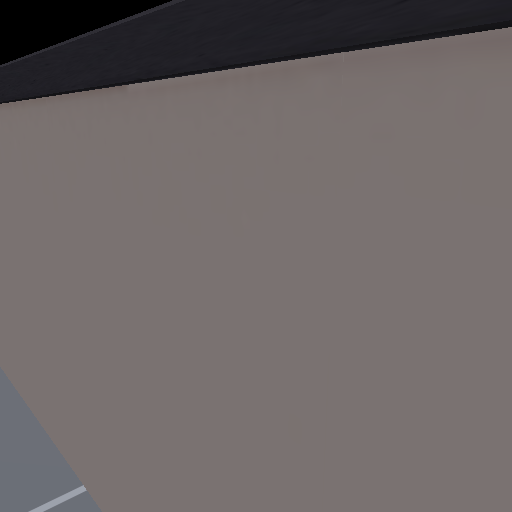

✅ Render OK: (512, 512, 3)


In [13]:
render_ok = False
try:
    frame = env_apple.render()
    if isinstance(frame, torch.Tensor):
        frame = frame.cpu().numpy()
    if frame.ndim == 4:
        frame = frame[0]
    if frame.dtype in (np.float32, np.float64):
        frame = (frame * 255).clip(0, 255).astype(np.uint8)
    img = Image.fromarray(frame)
    img.save(ARTIFACTS_DIR / "render_test_apple.png")
    display(img.resize((512, 512)))
    render_ok = True
    print(f"✅ Render OK: {frame.shape}")
except Exception as e:
    print(f"⚠️ Render not available (expected on CPU-only): {e}")


## Step 9 — Smoke Test (50 Random Steps per Env)

Run random actions to verify environments step without errors.


In [14]:
smoke_results = {}

for env_name, env in [("apple", env_apple), ("dishwipe", env_dw)]:
    obs, info = env.reset(seed=SEED)
    rewards, steps_done = [], 0
    terminated_count, truncated_count = 0, 0

    for step in range(CFG["smoke_steps"]):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        rewards.append(float(reward))
        steps_done += 1

        if terminated:
            terminated_count += 1
            obs, info = env.reset()
        if truncated:
            truncated_count += 1
            obs, info = env.reset()

    smoke_results[env_name] = {
        "steps_completed": steps_done,
        "mean_reward":     float(np.mean(rewards)),
        "std_reward":      float(np.std(rewards)),
        "min_reward":      float(np.min(rewards)),
        "max_reward":      float(np.max(rewards)),
        "terminated":      terminated_count,
        "truncated":       truncated_count,
    }

    print(f"\n{'='*50}")
    print(f"  {env_name.upper()} Smoke Test")
    print(f"{'='*50}")
    for k, v in smoke_results[env_name].items():
        print(f"  {k:20s}: {v}")

with open(ARTIFACTS_DIR / "smoke_results.json", "w") as f:
    json.dump(smoke_results, f, indent=2)
print(f"\nSaved: smoke_results.json")



  APPLE Smoke Test
  steps_completed     : 50
  mean_reward         : nan
  std_reward          : nan
  min_reward          : nan
  max_reward          : nan
  terminated          : 0
  truncated           : 0


ValueError: cannot convert float NaN to integer

## Step 10 — Reproducibility Check


In [ ]:
# Same seed → same initial observation
obs1, _ = env_apple.reset(seed=42)
obs2, _ = env_apple.reset(seed=42)
assert np.allclose(obs1, obs2), "Reproducibility FAILED!"
print("✅ Reproducibility check PASSED (seed=42)")

obs3, _ = env_apple.reset(seed=123)
assert not np.allclose(obs1, obs3), "Different seeds should give different obs!"
print("✅ Different seeds give different observations")


## Step 11 — Save Artifacts & MLflow


In [ ]:
import subprocess

# pip freeze
try:
    result = subprocess.run(
        [sys.executable, "-m", "pip", "freeze"],
        capture_output=True, text=True, timeout=30,
    )
    (ARTIFACTS_DIR / "requirements.txt").write_text(result.stdout)
    print(f"Saved: requirements.txt ({len(result.stdout.splitlines())} packages)")
except Exception as e:
    print(f"⚠️ pip freeze failed: {e}")

# Save config
with open(ARTIFACTS_DIR / "nb01_config.json", "w") as f:
    json.dump(CFG, f, indent=2)

# MLflow
if MLFLOW_OK:
    try:
        with mlflow.start_run(run_name="NB01_setup_smoke"):
            mlflow.set_tags({"notebook": "NB01", "task": "setup"})
            mlflow.log_params(CFG)
            mlflow.log_metrics({
                "apple_obs_dim": obs_a.shape[0],
                "apple_act_dim": env_apple.action_space.shape[0],
                "dishwipe_obs_dim": obs_d.shape[0],
                "dishwipe_act_dim": env_dw.action_space.shape[0],
                "smoke_apple_mean_reward": smoke_results["apple"]["mean_reward"],
                "smoke_dishwipe_mean_reward": smoke_results["dishwipe"]["mean_reward"],
            })
            mlflow.log_artifacts(str(ARTIFACTS_DIR))
        print("✅ MLflow run logged")
    except Exception as e:
        print(f"⚠️ MLflow logging failed: {e}")
else:
    csv_log({
        "timestamp": datetime.datetime.now().isoformat(),
        "apple_obs_dim": obs_a.shape[0],
        "apple_act_dim": env_apple.action_space.shape[0],
        "dishwipe_obs_dim": obs_d.shape[0],
        "dishwipe_act_dim": env_dw.action_space.shape[0],
    })
    print("📝 Logged to CSV fallback")


## Results Summary


In [ ]:
print("=" * 60)
print("  NB01 — Setup & Smoke Test Results")
print("=" * 60)
print(f"  Apple env     : {apple_spec['env_id']}")
print(f"    obs shape   : {apple_spec['obs_shape']}")
print(f"    act shape   : {apple_spec['act_shape']} ({apple_spec['dof']} DOF)")
print(f"  DishWipe env  : {dishwipe_spec['env_id']}")
print(f"    obs shape   : {dishwipe_spec['obs_shape']}")
print(f"    act shape   : {dishwipe_spec['act_shape']} ({dishwipe_spec['dof']} DOF)")
print(f"  Robot         : unitree_g1 (full body, free-floating root)")
print(f"  Total joints  : {joint_info.get('total_dof', 'N/A')}")
print(f"  Balance API   : standing={has_standing}, fallen={has_fallen}")
print(f"  Render        : {'OK' if render_ok else 'Not available (CPU-only)'}")
print(f"  Smoke test    : PASSED ✅")
print("=" * 60)


## Artifacts

| File | Description |
|------|-------------|
| `env_spec_apple.json` | Apple env obs/act shapes, DOF, robot info |
| `env_spec_dishwipe.json` | DishWipe env obs/act shapes, DOF, robot info |
| `active_joints_fullbody.json` | All 37 joints grouped by body part |
| `smoke_results.json` | 50-step smoke test stats for both envs |
| `requirements.txt` | pip freeze snapshot |
| `nb01_config.json` | Config used |
| `render_test_apple.png` | Render frame (if Vulkan available) |


In [ ]:
env_apple.close()
env_dw.close()
print("✅ NB01 Complete — Both environments verified")


## Notes

- Full-body G1 has **37 DOF** (12 legs + 1 torso + 10 arms + 14 fingers)
- Root is **free-floating** → robot CAN fall over
- `is_fallen()` checks if torso height drops below threshold
- Apple env needs `download_asset()` for apple/bowl meshes
- DishWipe env uses `dirt_grid.py` (VirtualDirtGrid 10×10)
- Render may fail on CPU-only (Vulkan required) — this is expected

### References
- [ManiSkill Documentation](https://maniskill.readthedocs.io/)
- Unitree G1 robot URDF: `g1.urdf` (37 DOF full body)
- Custom envs: `src/envs/apple_fullbody_env.py`, `src/envs/dishwipe_fullbody_env.py`
